# Q4: PCA and K-Means Clustering

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

# Load data
df = pd.read_csv('data/mobile_price.csv')
X = df.drop('price_range', axis=1).values
y = df['price_range'].values
print(f"Features shape: {X.shape}, Labels shape: {y.shape}")

Features shape: (2000, 20), Labels shape: (2000,)


## 4(a) Standardize features using z-score (StandardScaler)

In [2]:
# Z-score standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Scaled features - mean: {X_scaled.mean(axis=0)[:3].round(6)}, std: {X_scaled.std(axis=0)[:3].round(4)}")

Scaled features - mean: [ 0. -0. -0.], std: [1. 1. 1.]


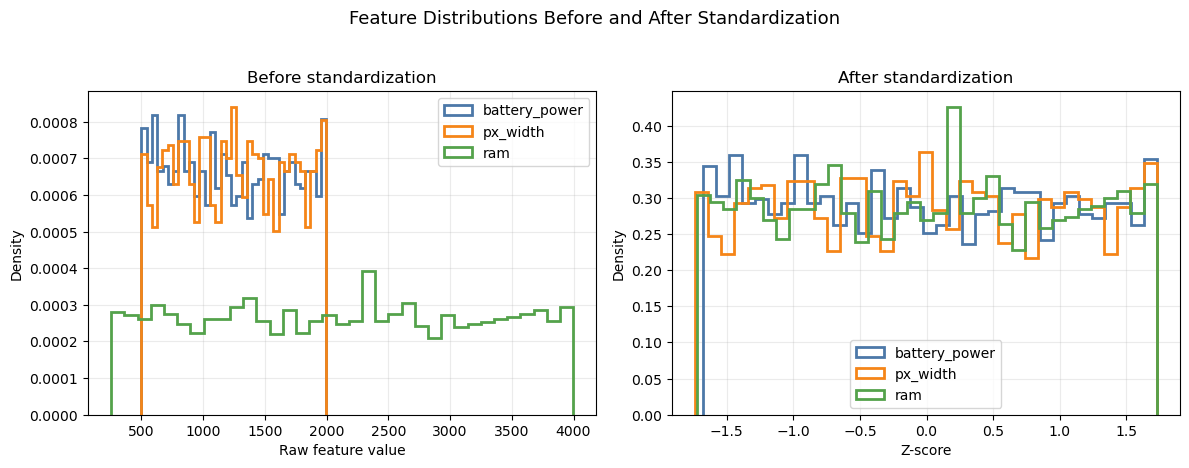

In [3]:
# Distribution comparison before and after standardization
feature_names = df.drop('price_range', axis=1).columns.tolist()
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_names)
selected_features = ['battery_power', 'px_width', 'ram']
feature_colors = ['#4c78a8', '#f58518', '#54a24b']

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for feature, color in zip(selected_features, feature_colors):
    axes[0].hist(df[feature], bins=35, density=True, histtype='step', linewidth=2, label=feature, color=color)
    axes[1].hist(X_scaled_df[feature], bins=35, density=True, histtype='step', linewidth=2, label=feature, color=color)

axes[0].set_title('Before standardization')
axes[0].set_xlabel('Raw feature value')
axes[0].set_ylabel('Density')
axes[0].grid(True, alpha=0.25)
axes[0].legend()

axes[1].set_title('After standardization')
axes[1].set_xlabel('Z-score')
axes[1].set_ylabel('Density')
axes[1].grid(True, alpha=0.25)
axes[1].legend()

plt.suptitle('Feature Distributions Before and After Standardization', fontsize=13, y=1.03)
plt.tight_layout()
plt.savefig('report/figures/q4_standardization_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## 4(b) PCA 2D projection with true class labels

Explained variance ratio: [0.08386288 0.08112475]
Total variance explained: 0.1650


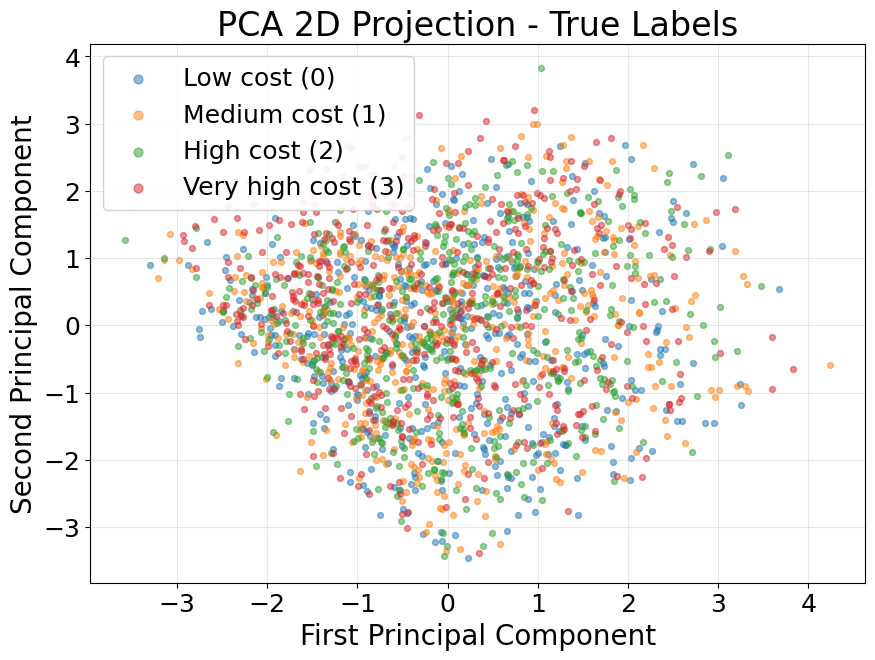

In [4]:
# PCA projection to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.4f}")

# Scatter plot with true labels
plt.figure(figsize=(10, 7))
class_names = ['Low cost (0)', 'Medium cost (1)', 'High cost (2)', 'Very high cost (3)']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for label in range(4):
    mask = y == label
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors[label], label=class_names[label], alpha=0.5, s=18)
plt.xlabel('First Principal Component', fontsize=20)
plt.ylabel('Second Principal Component', fontsize=20)
plt.title('PCA 2D Projection - True Labels', fontsize=24)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=18, markerscale=1.5, framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.savefig('report/figures/q4b_pca_true_labels.png', dpi=150, bbox_inches='tight')
plt.show()


## PCA explained variance diagnostics

Variance explained by first 2 PCs: 0.1650
Variance explained by first 5 PCs: 0.3716
Variance explained by first 10 PCs: 0.6314
PCs needed for >=80% variance: 14
PCs needed for >=90% variance: 16


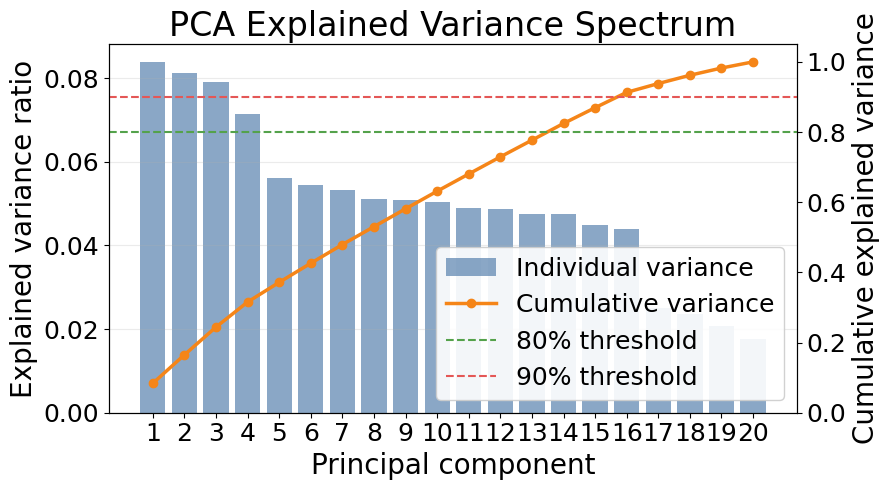

In [5]:
# Full PCA spectrum: how much information is retained by the first PCs?
pca_full = PCA(n_components=X_scaled.shape[1])
pca_full.fit(X_scaled)
explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

n80 = int(np.searchsorted(cumulative, 0.80) + 1)
n90 = int(np.searchsorted(cumulative, 0.90) + 1)
print(f'Variance explained by first 2 PCs: {cumulative[1]:.4f}')
print(f'Variance explained by first 5 PCs: {cumulative[4]:.4f}')
print(f'Variance explained by first 10 PCs: {cumulative[9]:.4f}')
print(f'PCs needed for >=80% variance: {n80}')
print(f'PCs needed for >=90% variance: {n90}')

fig, ax1 = plt.subplots(figsize=(9, 5))
pcs = np.arange(1, len(explained) + 1)
ax1.bar(pcs, explained, alpha=0.65, color='#4c78a8', label='Individual variance')
ax1.set_xlabel('Principal component', fontsize=20)
ax1.set_ylabel('Explained variance ratio', fontsize=20)
ax1.set_xticks(pcs)
ax1.tick_params(axis='both', labelsize=18)
ax1.grid(True, alpha=0.25, axis='y')

ax2 = ax1.twinx()
ax2.plot(pcs, cumulative, color='#f58518', marker='o', linewidth=2.5, label='Cumulative variance')
ax2.axhline(0.80, color='#54a24b', linestyle='--', linewidth=1.5, label='80% threshold')
ax2.axhline(0.90, color='#e45756', linestyle='--', linewidth=1.5, label='90% threshold')
ax2.set_ylabel('Cumulative explained variance', fontsize=20)
ax2.set_ylim(0, 1.05)
ax2.tick_params(axis='both', labelsize=18)

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(handles1 + handles2, labels1 + labels2, loc='lower right', fontsize=18, framealpha=0.9)
plt.title('PCA Explained Variance Spectrum', fontsize=24)
plt.tight_layout()
plt.savefig('report/figures/q4_pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()



## 4(c) K-Means on all standardized features

K-Means (all features) - Adjusted Rand Index: 0.0060


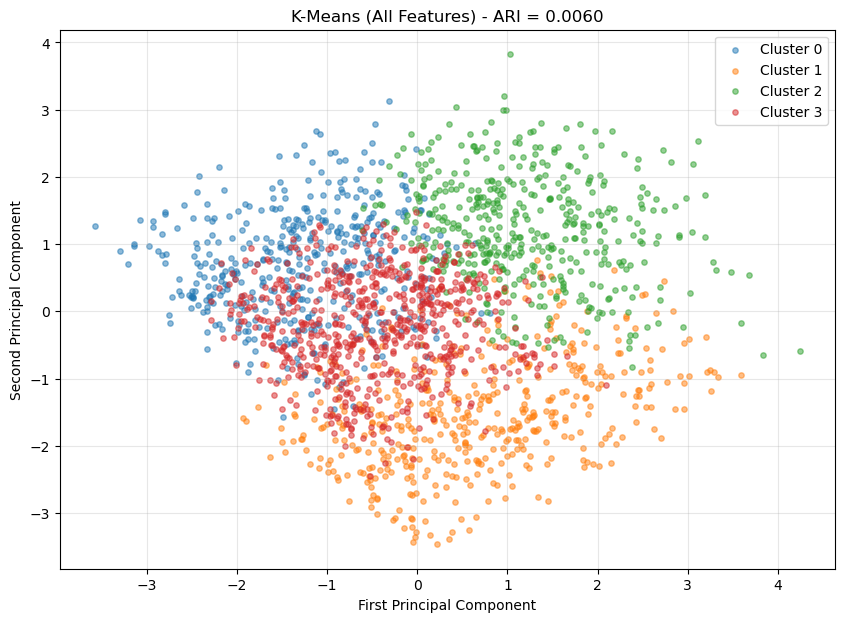

In [6]:
# K-Means on ALL standardized features
kmeans_full = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters_full = kmeans_full.fit_predict(X_scaled)

ari_full = adjusted_rand_score(y, clusters_full)
print(f"K-Means (all features) - Adjusted Rand Index: {ari_full:.4f}")

# Visualize on PCA 2D plane, colored by cluster assignment
plt.figure(figsize=(10, 7))
for c in range(4):
    mask = clusters_full == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors[c], label=f'Cluster {c}', alpha=0.5, s=15)
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title(f'K-Means (All Features) - ARI = {ari_full:.4f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('report/figures/q4c_kmeans_all_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 4(d) K-Means on PCA 2D features

K-Means (PCA 2D) - Adjusted Rand Index: 0.0017


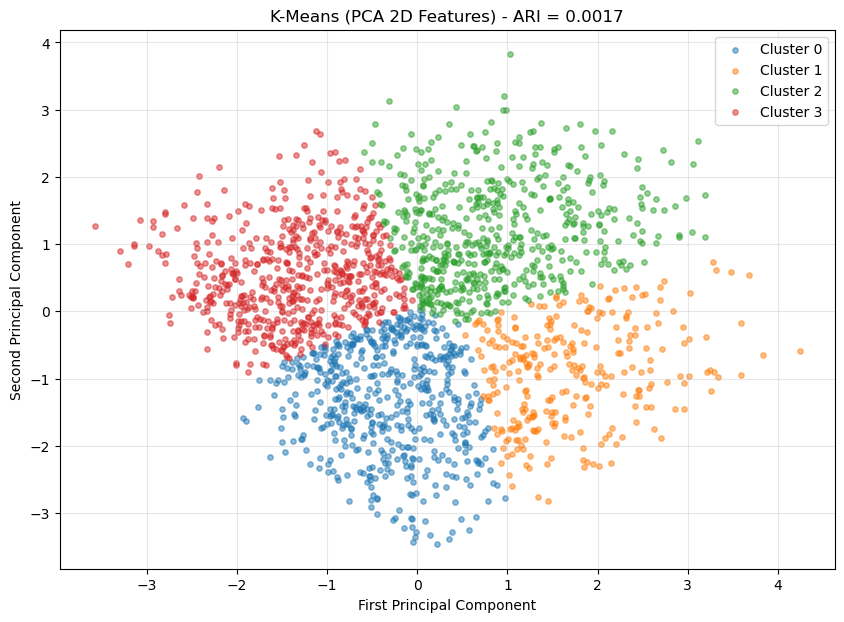

In [7]:
# K-Means on PCA 2D features
kmeans_pca = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters_pca = kmeans_pca.fit_predict(X_pca)

ari_pca = adjusted_rand_score(y, clusters_pca)
print(f"K-Means (PCA 2D) - Adjusted Rand Index: {ari_pca:.4f}")

# Visualize
plt.figure(figsize=(10, 7))
for c in range(4):
    mask = clusters_pca == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors[c], label=f'Cluster {c}', alpha=0.5, s=15)
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title(f'K-Means (PCA 2D Features) - ARI = {ari_pca:.4f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('report/figures/q4d_kmeans_pca_2d.png', dpi=150, bbox_inches='tight')
plt.show()

## 4(e) Observations

In [8]:
# Summary comparison
print("=== Clustering Performance Comparison ===")
print(f"K-Means (all {X_scaled.shape[1]} features): ARI = {ari_full:.4f}")
print(f"K-Means (PCA 2D features):        ARI = {ari_pca:.4f}")
print(f"\nPCA explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}% of total variance")

=== Clustering Performance Comparison ===
K-Means (all 20 features): ARI = 0.0060
K-Means (PCA 2D features):        ARI = 0.0017

PCA explained variance: 16.5% of total variance


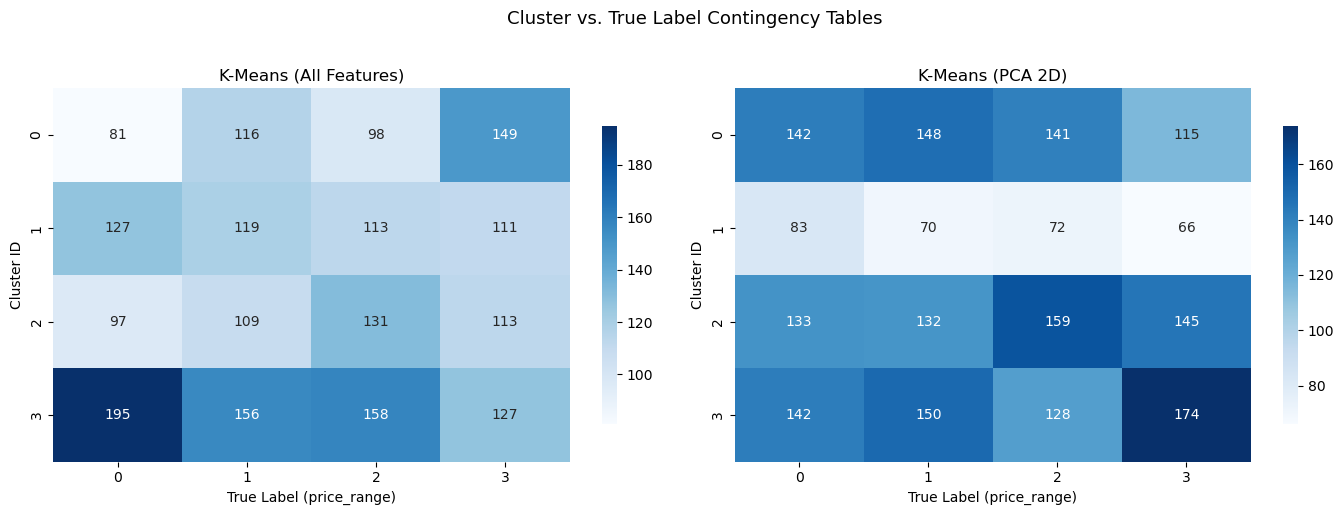

In [9]:
import seaborn as sns

# Contingency heatmaps: cluster assignment vs true labels
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, clusters, title in zip(axes, [clusters_full, clusters_pca],
                                 ['K-Means (All Features)', 'K-Means (PCA 2D)']):
    ct = pd.crosstab(pd.Series(clusters, name='Cluster'), pd.Series(y, name='True Label'))
    sns.heatmap(ct, annot=True, fmt='d', cmap='Blues', ax=ax, cbar_kws={'shrink': 0.8})
    ax.set_title(title)
    ax.set_xlabel('True Label (price_range)')
    ax.set_ylabel('Cluster ID')

plt.suptitle('Cluster vs. True Label Contingency Tables', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('report/figures/q4_contingency.png', dpi=150, bbox_inches='tight')
plt.show()

## 4(e) Observations

**PCA projection (4b):** The first two principal components explain only 16.5% of the total variance, meaning 83.5% of the information is lost in this 2D projection. The scatter plot shows heavy overlap among the 4 price-range classes, indicating that the class structure is not primarily captured by the top two principal components.

**K-Means on all features (4c) vs. PCA 2D (4d):**
- Both approaches yield very low ARI values: 0.0060 (all features) and 0.0017 (PCA 2D). An ARI near 0 indicates that the clustering is essentially random with respect to the true labels.
- K-Means on all 20 features (ARI=0.0060) slightly outperforms K-Means on 2D PCA features (ARI=0.0017), which is expected since reducing to 2 dimensions discards 83.5% of the variance.
- The poor performance of K-Means overall suggests that the price-range classes are not well-separated in Euclidean space — even with all features. K-Means assumes spherical, equally-sized clusters, which may not match the actual data distribution. The dataset likely has complex, non-linear decision boundaries that K-Means cannot capture.
- This contrasts with the SVM results in Q2 (>95% accuracy), confirming that price-range prediction requires a supervised approach with a non-linear decision boundary (SVM with RBF kernel), rather than unsupervised distance-based clustering.